# Flight Price Prediction

## Aim of the Project
Build and compare several machine learning models that predict the **ticket price**
of a domestic flight departing New York City (JFK, LGA, EWR) in 2013, using only
information that is known **before** the flight departs (route, carrier,
distance, date, and time of day).

## About the Dataset
The source data is the `nycflights13`-style flights table (via
[openintro.org](https://www.openintro.org/data/index.php?data=nycflights)),
containing ~32.7k domestic flights departing NYC airports in 2013.

> **Important note on the target variable:** the original dataset does **not**
> include a fare/price column — it only records flight times, delays, carrier,
> route, and distance. Since this project's goal is price prediction, a
> **synthetic `price` target was formulated** (see the *Target Variable
> Construction* section below) from a realistic fare-pricing formula driven only
> by pre-departure-known fields (distance, carrier, season, day type, time of
> day, origin) plus random noise. This keeps the target free of data leakage and
> lets the full regression pipeline (cleaning → EDA → feature engineering →
> modeling → evaluation → deployment) be demonstrated end to end. Because the
> price is simulated, treat the trained models as a **methodology
> demonstration**, not real fare predictions.


## Data Dictionary

| Column | Description |
|---|---|
| `year`, `month`, `day` | Date of departure |
| `dep_time`, `arr_time` | Departure and arrival times, local timezone |
| `dep_delay`, `arr_delay` | Departure and arrival delays, in minutes (negative = early) |
| `hour`, `minute` | Departure time broken into hour and minute |
| `carrier` | Two-letter carrier abbreviation (see `airlines` in the `nycflights13` package) |
| `tailnum` | Aircraft tail number |
| `flight` | Flight number |
| `origin`, `dest` | Origin and destination airport codes |
| `air_time` | Time spent in the air, in minutes |
| `distance` | Distance flown, in miles |
| `price` *(engineered)* | **Synthetic** ticket price in USD — formulated for this project (see below); not present in the source data |

Data source: https://www.openintro.org/data/index.php?data=nycflights


> **Note:** This notebook is the exploratory / narrative counterpart to the production pipeline in `src/` (preprocess.py, feature_engineering.py, train.py, evaluate.py, predict.py), which is what `main.py` and the `backend/` API actually run. Re-execute this notebook any time you want to explore the data or re-derive the charts in `charts/` interactively.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
RNG = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
%matplotlib inline

# Project folder structure 

PROJECT_ROOT = Path.cwd().parent  # notebook lives in notebooks/, project root is one level up
CLEAN_DIR   = PROJECT_ROOT / "data" / "clean_data"
CHARTS_DIR  = PROJECT_ROOT / "charts"
MODELS_DIR  = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "outputs"
SCRIPT_DIR  = PROJECT_ROOT / "src"

for d in [CLEAN_DIR, CHARTS_DIR, MODELS_DIR, REPORTS_DIR, SCRIPT_DIR]:
    d.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
for d in [CLEAN_DIR, CHARTS_DIR, MODELS_DIR, REPORTS_DIR, SCRIPT_DIR]:
    print(" -", d.name + "/")

Project root: C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\flight prediction
 - clean_data/
 - charts/
 - models/
 - reports/
 - script/


In [2]:
df = pd.read_csv("../data/raw/data.csv")
print("Raw shape:", df.shape)
df.head()

Raw shape: (32735, 16)


,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute
0,2013,6,30,940,15,1216,-4,VX,N626VA,407,JFK,LAX,313,2475,9,40
1,2013,5,7,1657,-3,2104,10,DL,N3760C,329,JFK,SJU,216,1598,16,57
2,2013,12,8,859,-1,1238,11,DL,N712TW,422,JFK,LAX,376,2475,8,59
3,2013,5,14,1841,-4,2122,-34,DL,N914DL,2391,JFK,TPA,135,1005,18,41
4,2013,7,21,1102,-3,1230,-8,9E,N823AY,3652,LGA,ORF,50,296,11,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32735 entries, 0 to 32734
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   year       32735 non-null  int64 
 1   month      32735 non-null  int64 
 2   day        32735 non-null  int64 
 3   dep_time   32735 non-null  int64 
 4   dep_delay  32735 non-null  int64 
 5   arr_time   32735 non-null  int64 
 6   arr_delay  32735 non-null  int64 
 7   carrier    32735 non-null  object
 8   tailnum    32735 non-null  object
 9   flight     32735 non-null  int64 
 10  origin     32735 non-null  object
 11  dest       32735 non-null  object
 12  air_time   32735 non-null  int64 
 13  distance   32735 non-null  int64 
 14  hour       32735 non-null  int64 
 15  minute     32735 non-null  int64 
dtypes: int64(12), object(4)
memory usage: 4.0+ MB


## 1. Data Cleaning

Steps: check missing values, remove duplicate rows, fix a known data quirk
(midnight departures encoded as hour `24` / `dep_time` `2400`), and flag
outliers in the numeric columns using the IQR method.

### **Check for Missing Values**

In [4]:
print("Missing values per column:")
print(df.isna().sum())

before = len(df)
df = df.drop_duplicates()
print(f"\nDuplicate rows removed: {before - len(df)}")

Missing values per column:
year         0
month        0
day          0
dep_time     0
dep_delay    0
arr_time     0
arr_delay    0
carrier      0
tailnum      0
flight       0
origin       0
dest         0
air_time     0
distance     0
hour         0
minute       0
dtype: int64

Duplicate rows removed: 0


### **Convert time from 1-24 hours to 0-23 hours**

In [5]:
# The source data encodes midnight departures as hour = 24 /dep_time = 2400
# Noemalize these to hour = 0, to downstream hour based features are valid (0-23).

midnight_mask = df["hour"] == 24
print(f"Rows with hour == 24 (midnight quirk): {midnight_mask.sum()}")
df.loc[midnight_mask, "hour"] = 0
df.loc[midnight_mask, "dep_time"] = df.loc[midnight_mask, "dep_time"] - 2400

Rows with hour == 24 (midnight quirk): 3


### Detect and treat outliers (IQR method)

In [6]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

print("IQR outlier:")
for col in ["distance", "air_time", "dep_delay", "arr_delay"]:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f" {col:10s}: bounds=({lo:8.1f}, {hi:8.1f}) outliers = {n_out}")


IQR outlier:
 distance  : bounds=(  -831.5,   2724.5) outliers = 67
 air_time  : bounds=(   -81.5,    354.5) outliers = 692
 dep_delay : bounds=(   -29.0,     35.0) outliers = 4339
 arr_delay : bounds=(   -63.5,     60.5) outliers = 2817


`dep_delay`, `arr_delay`, and `air_time` are only known **after** a flight
departs/lands, so they will be dropped in the leakage-removal step below and
their outliers don't need treatment for this project. `distance` **is** kept
as a modeling feature, so its outliers (unusually long-haul routes) are
trimmed to keep the price formula and models well-behaved.

In [7]:
lo, hi = iqr_bounds(df["distance"])
before = len(df)
df=df[(df["distance"] >= lo) & (df["distance"] <= hi)].reset_index(drop=True)
print(f"Row dropped as distance outliers: {before - len(df)}")
print(f"Remaining rows: {len(df)}")

Row dropped as distance outliers: 67
Remaining rows: 32668


## Target Variable Construction — Synthetic `price`

Since no fare data exists in the source, `price` is formulated from a
realistic airfare pricing model built **only from pre-departure-known
fields**, so there's no leakage from the outcome of the flight:

`price = base_fare + distance^0.88 rate + carrier premium + summer/holiday premium
         + weekend premium + peak-hour premium − red-eye discount + origin premium + noise`

The exponent on distance (<1) reflects the real-world pattern that longer
flights cost less per mile than short ones. Carrier premiums loosely mimic
legacy-vs-budget carrier positioning. Gaussian noise is added so the target
isn't perfectly deterministic from the features — otherwise every model
would trivially score R²≈1.

In [8]:
date = pd.to_datetime(dict(year=df.year, month=df.month, day=df.day))
weekday = date.dt.weekday  # Monday=0 ... Sunday=6

carrier_premium = {
    "UA": 18, "AA": 22, "DL": 20, "US": 12, "B6": 8, "VX": 25,
    "9E": 5, "EV": 0, "F9": -10, "FL": -8, "HA": 30, "MQ": 2,
    "OO": 3, "WN": -15, "YV": 0, "AS": 15,
}
carrier_prem = df["carrier"].map(carrier_premium).fillna(0)

base_fare = 45
distance_component = 0.11 * df["distance"] ** 0.88
season_prem = df["month"].isin([6, 7, 8, 12]).astype(int) * 25
weekend_prem = weekday.isin([4, 6]).astype(int) * 15
peak_prem = (df["hour"].between(6, 9).astype(int) * 12
             + df["hour"].between(16, 19).astype(int) * 12)
redeye_disc = (df["hour"] < 5).astype(int) * -20
origin_prem = df["origin"].map({"JFK": 10, "EWR": 4, "LGA": 0}).fillna(0)

noise = RNG.normal(0, 18, size=len(df))
mult_noise = RNG.normal(1, 0.05, size=len(df))

raw_price = (base_fare + distance_component + carrier_prem + season_prem
             + weekend_prem + peak_prem + redeye_disc + origin_prem + noise) * mult_noise
df["price"] = raw_price.clip(lower=39).round(2)

df["price"].describe()

count   32668.00
mean      127.78
std        44.05
min        39.00
25%        95.31
50%       122.31
75%       155.72
max       291.61
Name: price, dtype: float64

In [9]:
df.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,price
0,2013,6,30,940,15,1216,-4,VX,N626VA,407,JFK,LAX,313,2475,9,40,246.28
1,2013,5,7,1657,-3,2104,10,DL,N3760C,329,JFK,SJU,216,1598,16,57,151.56
2,2013,12,8,859,-1,1238,11,DL,N712TW,422,JFK,LAX,376,2475,8,59,245.00
3,2013,5,14,1841,-4,2122,-34,DL,N914DL,2391,JFK,TPA,135,1005,18,41,155.22
4,2013,7,21,1102,-3,1230,-8,9E,N823AY,3652,LGA,ORF,50,296,11,2,71.77


### Removing leakage, irrelevant, and redundant columns

- **Leakage** (only knowable after departure/arrival): `dep_delay`, `arr_delay`, `arr_time`, `air_time`
- **Redundant**: `year` (constant, all 2013), `dep_time` (redundant with the already-provided `hour`/`minute`)
- **Irrelevant identifiers**: `flight` (flight number, an arbitrary label), `tailnum` (individual aircraft, too high-cardinality to generalize from)

In [10]:
drop_cols = ["year", "dep_time", "arr_time", "dep_delay", "arr_delay", "air_time", "flight", "tailnum"]
df_model = df.drop(columns=drop_cols)
print("Columns kept for modeling:", list(df_model.columns))
df_model.head()

Columns kept for modeling: ['month', 'day', 'carrier', 'origin', 'dest', 'distance', 'hour', 'minute', 'price']


,month,day,carrier,origin,dest,distance,hour,minute,price
0,6,30,VX,JFK,LAX,2475,9,40,246.28
1,5,7,DL,JFK,SJU,1598,16,57,151.56
2,12,8,DL,JFK,LAX,2475,8,59,245.00
3,5,14,DL,JFK,TPA,1005,18,41,155.22
4,7,21,9E,LGA,ORF,296,11,2,71.77


### **EDA and Visualization**

In [11]:
def savefig(name):
    plt.savefig(CHARTS_DIR / name, dpi=300, bbox_inches="tight")

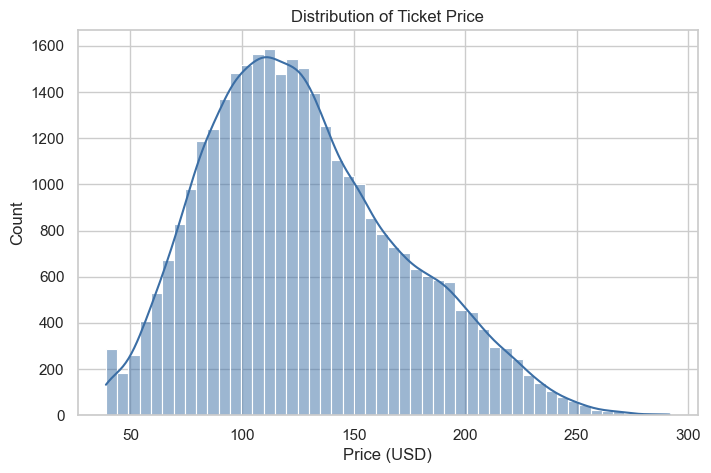

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df_model["price"], bins=50, kde=True, color="#3b6ea5")
plt.title("Distribution of Ticket Price")
plt.xlabel("Price (USD)")
plt.tight_layout
savefig("01_distribution_of_ticket_price.png")
plt.show()

The price distribution is right-skewed with most fares clustering between
roughly **\$80 – \$180**, and a long tail of pricier long-haul flights — consistent
with how the synthetic formula scales with distance.

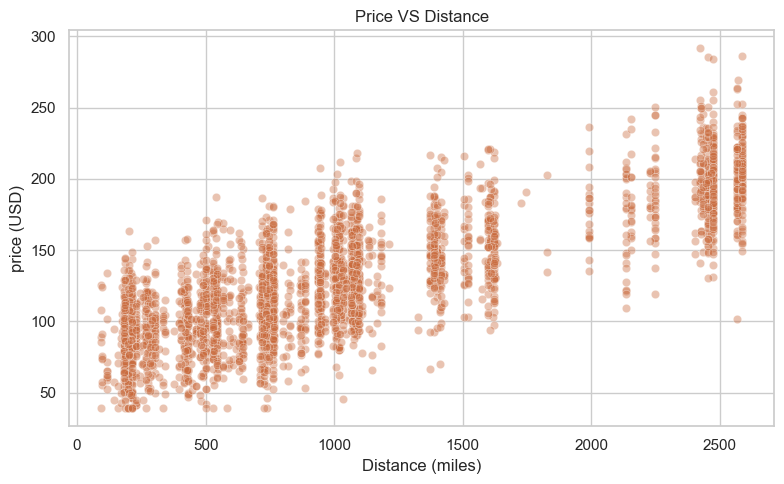

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_model.sample(3000, random_state=42), x = "distance", y = "price",
               alpha=0.4, color="#c96a3c")
plt.title("Price VS Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("price (USD)")
plt.tight_layout()
savefig("02_price_vs_distance.png")
plt.show()
           

Price rises with distance but at a decreasing rate (the concave shape),
matching the sub-linear distance term used to build the target — short
regional hops aren't proportionally cheaper per mile than long-haul flights.

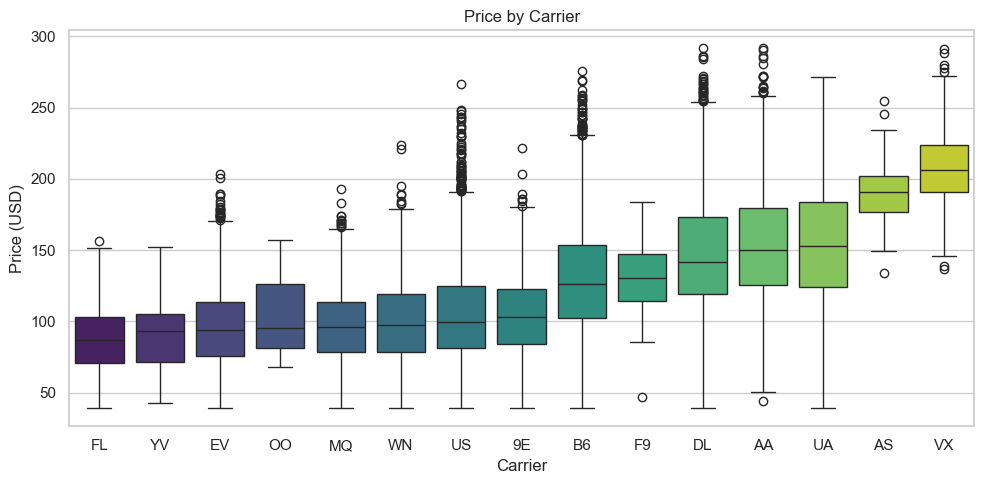

In [14]:
plt.figure(figsize=(10, 5))
order = df_model.groupby("carrier")["price"].median().sort_values().index
sns.boxplot(data=df_model, x="carrier", y="price", order=order, palette="viridis")
plt.title("Price by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Price (USD)")
plt.tight_layout()
savefig("03_price_by_carrier.png")
plt.show()

Median fares vary noticeably by carrier — this reflects the carrier
premium/discount terms baked into the pricing formula (e.g. `HA`/`VX` skew
pricier, `WN`/`F9` skew cheaper), similar to how budget vs. legacy carriers
tend to price differently in the real world.

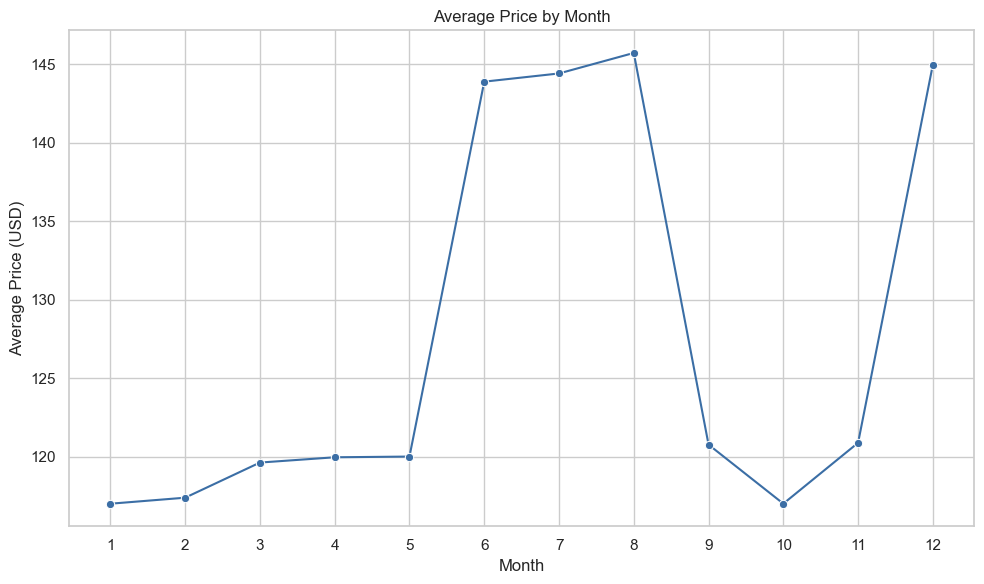

In [15]:
plt.figure(figsize=(10, 6))
monthly = df_model.groupby("month")["price"].mean()
sns.lineplot(x=monthly.index, y=monthly.values, marker="o", color="#3b6ea5")
plt.title("Average Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price (USD)")
plt.xticks(range(1, 13))
plt.tight_layout()
savefig("04_price_by_month.png")
plt.show()

Average prices peak in the summer months and December, reflecting the
seasonal/holiday premium.

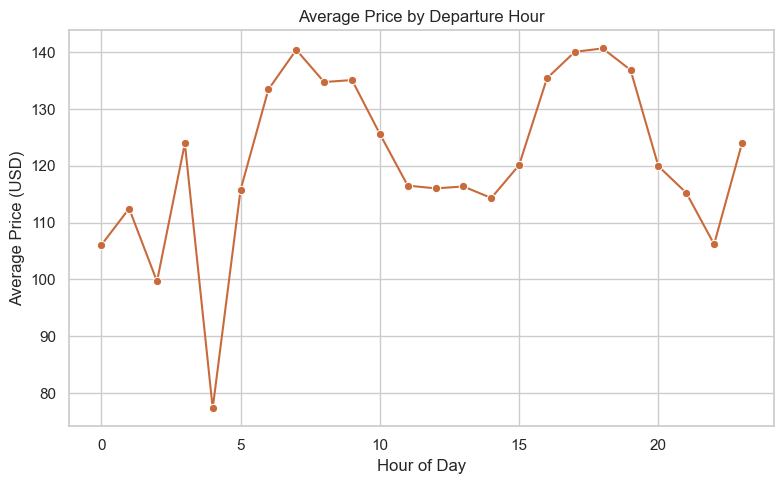

In [16]:
plt.figure(figsize=(8, 5))
hourly = df_model.groupby("hour")["price"].mean()
sns.lineplot(x=hourly.index, y=hourly.values, marker="o", color="#c96a3c")
plt.title("Average Price by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Price (USD)")
plt.tight_layout()
savefig("05_price_by_hour.png")
plt.show()

Prices dip for the earliest (red-eye) departures and rise around the
morning and evening commute peaks — again tracking the peak-hour/red-eye
terms in the pricing formula.

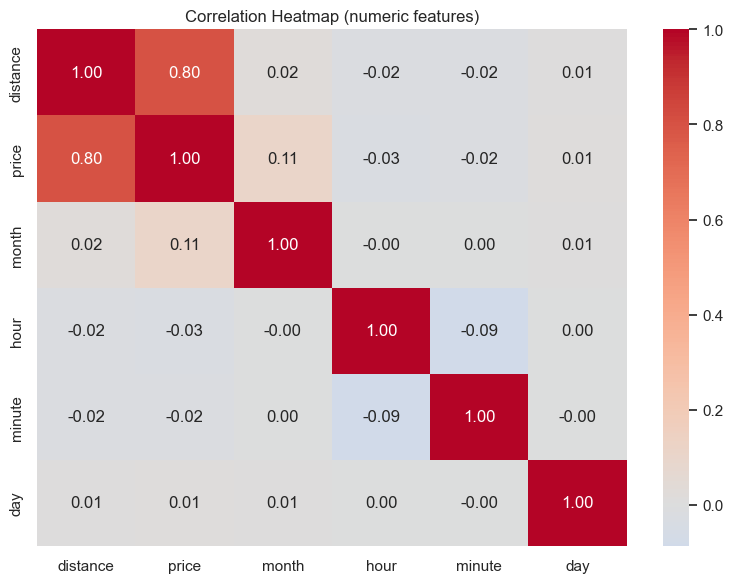

In [17]:
plt.figure(figsize=(8, 6))
num_cols_corr = ["distance", "price", "month", "hour", "minute", "day"]
sns.heatmap(df_model[num_cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.tight_layout()
savefig("06_correlation_heatmap.png")
plt.show()

`distance` is by far the strongest numeric correlate of `price`, as
expected. `month` and `hour` show weaker but non-trivial relationships,
consistent with the seasonal and time-of-day premiums.

## 3. Feature Engineering

- `weekday` / `is_weekend` — derived from the flight date
- `season` — grouped from `month`
- `time_of_day` — grouped from `hour` (Night/Morning/Afternoon/Evening)
- `route` and frequency encodings for `route` / `dest` (avoids exploding
  one-hot dimensionality from 102 destinations)
- Cyclical (sin/cos) encodings of `month` and `hour` so the model sees
  December and January, or 23:00 and 00:00, as close together rather than
  far apart on a raw numeric scale

In [18]:
df_model["weekday"] = weekday.values
df_model["is_weekend"] = df_model["weekday"].isin([5, 6]).astype(int)

season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Fall", 10: "Fall", 11: "Fall"}
df_model["season"] = df_model["month"].map(season_map)

def time_bucket(h):
    if h < 5: return "Night"
    if h < 12: return "Morning"
    if h < 17: return "Afternoon"
    if h < 21: return "Evening"
    return "Night"

df_model["time_of_day"] = df_model["hour"].apply(time_bucket)

df_model["route"] = df_model["origin"] + "_" + df_model["dest"]
route_freq_map = df_model["route"].value_counts(normalize=True)
df_model["route_freq"] = df_model["route"].map(route_freq_map)

dest_freq_map = df_model["dest"].value_counts(normalize=True)
df_model["dest_freq"] = df_model["dest"].map(dest_freq_map)

df_model["month_sin"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model["month"] / 12)
df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

df_model.to_csv(CLEAN_DIR / "flights_clean.csv", index=False)
print("Saved cleaned dataset to", CLEAN_DIR / "cleaned_flights_clean.csv")
print(df_model.shape)
df_model.head()


Saved cleaned dataset to C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\flight prediction\data\clean_data\cleaned_flights_clean.csv
(32668, 20)


,month,day,carrier,origin,dest,distance,hour,minute,price,weekday,is_weekend,season,time_of_day,route,route_freq,dest_freq,month_sin,month_cos,hour_sin,hour_cos
0,6,30,VX,JFK,LAX,2475,9,40,246.28,6,1,Summer,Morning,JFK_LAX,0.03,0.05,0.00,-1.00,0.71,-0.71
1,5,7,DL,JFK,SJU,1598,16,57,151.56,1,0,Spring,Afternoon,JFK_SJU,0.01,0.02,0.50,-0.87,-0.87,-0.50
2,12,8,DL,JFK,LAX,2475,8,59,245.00,6,1,Winter,Morning,JFK_LAX,0.03,0.05,-0.00,1.00,0.87,-0.50
3,5,14,DL,JFK,TPA,1005,18,41,155.22,1,0,Spring,Evening,JFK_TPA,0.01,0.02,0.50,-0.87,-1.00,-0.00
4,7,21,9E,LGA,ORF,296,11,2,71.77,6,1,Summer,Morning,LGA_ORF,0.00,0.00,-0.50,-0.87,0.26,-0.97


## **4. Model Training**

### **4.1 Train/Test Split**

In [19]:
from sklearn.model_selection import train_test_split

target = "price"
# dest/route are dropped in favour of their frequency-encoded versions
X = df_model.drop(columns=[target, "dest", "route"])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (26134, 17) Test shape: (6534, 17)


### 4.2 Encoding and Scaling

Numeric features are standardized; low-cardinality categoricals (`carrier`, `origin`, `season`, `time_of_day`) are one-hot encoded inside a shared `ColumnTransformer` so every model uses an identical, leakage-safe preprocessing pipeline fit only on the training split.

In [20]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = ["carrier", "origin", "season", "time_of_day"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

Numeric features: ['month', 'day', 'distance', 'hour', 'minute', 'weekday', 'is_weekend', 'route_freq', 'dest_freq', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']
Categorical features: ['carrier', 'origin', 'season', 'time_of_day']


In [21]:
# imstall ligthgbm
#%pip install lightgbm

### **Model Training**

In [22]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

base_models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, random_state=42, verbosity=-1),
}

fitted_pipelines = {}
predictions = {}

for name, model in base_models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    predictions[name] = pipe.predict(X_test)
    print(f"Trained: {name}")

Trained: LinearRegression
Trained: RandomForest
Trained: XGBoost
Trained: LightGBM


In [23]:
stacking_model = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)),
        ("xgb", XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.08, random_state=42, n_jobs=-1)),
        ("lgbm", LGBMRegressor(n_estimators=200, max_depth=5, learning_rate=0.08, random_state=42, verbosity=-1)),
    ],
    final_estimator=Ridge(),
    n_jobs=-1,
)
stack_pipe = Pipeline([("prep", preprocess), ("model", stacking_model)])
stack_pipe.fit(X_train, y_train)
fitted_pipelines["StackingEnsemble"] = stack_pipe
predictions["StackingEnsemble"] = stack_pipe.predict(X_test)
print("Trained: StackingEnsemble")

Trained: StackingEnsemble


### Model Evaluation

Since `price` is continuous, evaluation uses regression metrics — **RMSE**,
**MAE**, and **R²**.

In [24]:
results = {}
for name, pred in predictions.items():
    rmse = mean_squared_error(y_test, pred) ** 0.5
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

report_df = pd.DataFrame(results).T.sort_values("RMSE")
report_df.to_csv(REPORTS_DIR / "model_report.csv")
print("Saved model to", REPORTS_DIR / "model_report.csv")
report_df

Saved model to C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\flight prediction\reports\model_report.csv


,RMSE,MAE,R2
StackingEnsemble,19.66,15.60,0.80
LightGBM,19.78,15.69,0.80
XGBoost,20.01,15.86,0.80
RandomForest,20.60,16.31,0.78
LinearRegression,20.79,16.60,0.78


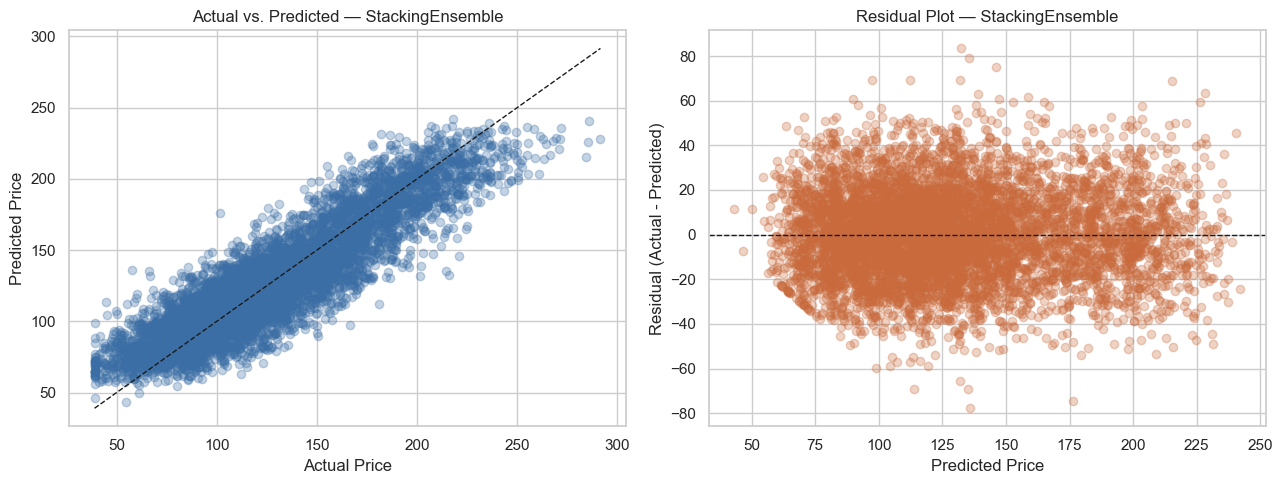

In [25]:
best_name = report_df.index[0]
best_pred = predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, best_pred, alpha=0.3, color="#3b6ea5")
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title(f"Actual vs. Predicted — {best_name}")

residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.3, color="#c96a3c")
axes[1].axhline(0, color="k", linestyle="--", lw=1)
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title(f"Residual Plot — {best_name}")

plt.tight_layout()
savefig(REPORTS_DIR / f"actual_vs_predicted_{best_name}.png")
plt.show()

Points hugging the diagonal in the left panel, and residuals scattered
randomly around zero with no funnel or curve in the right panel, indicate the
best model captures the price structure well without strong systematic bias.

### Model Comparison

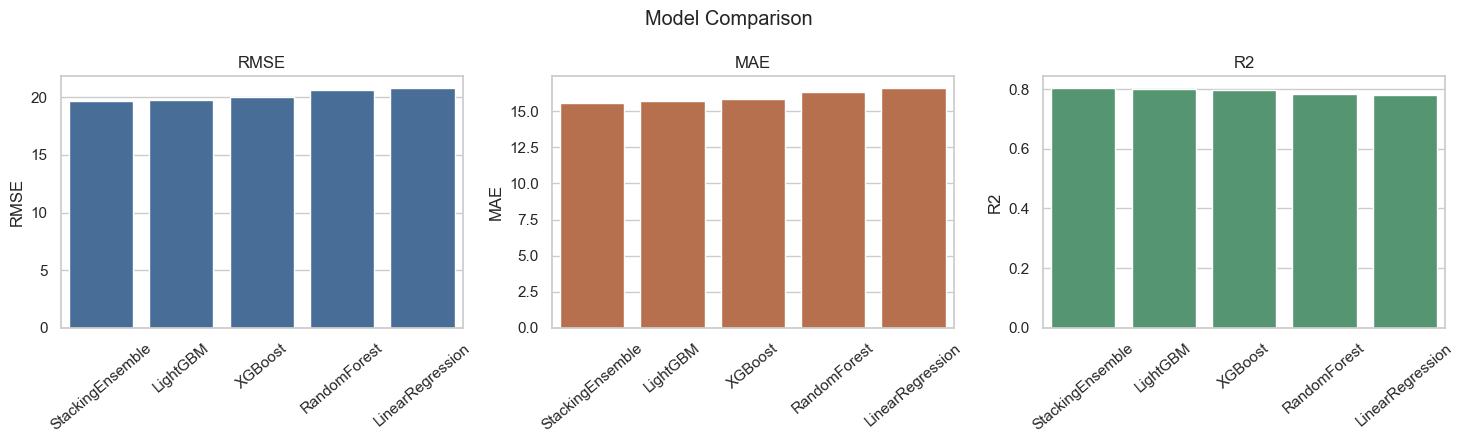

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["RMSE", "MAE", "R2"]
colors = ["#3b6ea5", "#c96a3c", "#4c9f70"]
for ax, metric, color in zip(axes, metrics, colors):
    sns.barplot(x=report_df.index, y=report_df[metric], ax=ax, color=color)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=40)
plt.suptitle("Model Comparison")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_comparison.png")
plt.show()

### Save Models

In [27]:
import joblib

model_folder_map = {
    "RandomForest": "Random Forest",
    "XGBoost": "XGBoost",
    "LightGBM": "LightGBM",
    "StackingEnsemble": "Stacking Ensemble",
}

for key, folder_name in model_folder_map.items():
    out_dir = MODELS_DIR / folder_name
    out_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(fitted_pipelines[key], out_dir / "model.joblib")
    print(f"Saved {key} -> {out_dir / 'model.joblib'}")

joblib.dump(fitted_pipelines["LinearRegression"], MODELS_DIR / "linear_regression.joblib")
print("Saved LinearRegression -> models/linear_regression.joblib")

print(f"\nBest model on the test set: {best_name}")
print(report_df.loc[best_name])

Saved RandomForest -> C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\flight prediction\models\Random Forest\model.joblib
Saved XGBoost -> C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\flight prediction\models\XGBoost\model.joblib
Saved LightGBM -> C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\flight prediction\models\LightGBM\model.joblib
Saved StackingEnsemble -> C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\flight prediction\models\Stacking Ensemble\model.joblib
Saved LinearRegression -> models/linear_regression.joblib

Best model on the test set: StackingEnsemble
RMSE   19.66
MAE    15.60
R2      0.80
Name: StackingEnsemble, dtype: float64


## Prediction Pipeline

The function below reproduces every cleaning/feature-engineering step above
for a single new flight record, then feeds it through the saved best model.
A standalone, reusable version of this logic also lives in
`script/prediction_pipeline.py`.

In [29]:
def prepare_single_flight(year, month, day, hour, minute, carrier, origin, dest, distance):
    """Turn one raw flight description into a model-ready feature row."""
    date = pd.Timestamp(year=year, month=month, day=day)
    weekday_ = date.weekday()

    row = {
        "month": month, "day": day, "carrier": carrier, "origin": origin,
        "distance": distance, "hour": hour, "minute": minute,
        "weekday": weekday_, "is_weekend": int(weekday_ in (5, 6)),
        "season": season_map[month],
        "time_of_day": time_bucket(hour),
        "route_freq": route_freq_map.get(f"{origin}_{dest}", 0.0),
        "dest_freq": dest_freq_map.get(dest, 0.0),
        "month_sin": np.sin(2 * np.pi * month / 12),
        "month_cos": np.cos(2 * np.pi * month / 12),
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
    }
    return pd.DataFrame([row])[X.columns]


sample = prepare_single_flight(
    year=2013, month=7, day=19, hour=8, minute=30,
    carrier="DL", origin="JFK", dest="LAX", distance=2475,
)
best_model = fitted_pipelines[best_name]
predicted_price = best_model.predict(sample)[0]
print(f"Sample flight: JFK -> LAX, DL, 08:30, July 19")
print(f"Predicted price ({best_name}): ${predicted_price:.2f}")

Sample flight: JFK -> LAX, DL, 08:30, July 19
Predicted price (StackingEnsemble): $232.23


In [38]:
# Multiple flight samples
sample_flights = [
    {
        "year": 2013,
        "month": 7,
        "day": 19,
        "hour": 8,
        "minute": 30,
        "carrier": "DL",
        "origin": "JFK",
        "dest": "LAX",
        "distance": 2475
    },
    {
        "year": 2013,
        "month": 5,
        "day": 3,
        "hour": 15,
        "minute": 10,
        "carrier": "9E",
        "origin": "LGA",
        "dest": "ORF",
        "distance": 1598
    },
    {
        "year": 2013,
        "month": 11,
        "day": 12,
        "hour": 22,
        "minute": 40,
        "carrier": "VX",
        "origin": "JFK",
        "dest": "SJU",
        "distance": 1598
    }
]

# Select the best-performing model
best_model = fitted_pipelines[best_name]

# Predict fare for each flight
for i, flight in enumerate(sample_flights, start=1):

    sample = prepare_single_flight(
        year=flight["year"],
        month=flight["month"],
        day=flight["day"],
        hour=flight["hour"],
        minute=flight["minute"],
        carrier=flight["carrier"],
        origin=flight["origin"],
        dest=flight["dest"],
        distance=flight["distance"]
    )

    predicted_price = best_model.predict(sample)[0]

    print(f"Sample Flight {i}")
    print(f"Route           : {flight['origin']} -> {flight['dest']}")
    print(f"Carrier         : {flight['carrier']}")
    print(f"Departure       : {flight['hour']:02d}:{flight['minute']:02d}")
    print(f"Date            : {flight['year']}-{flight['month']:02d}-{flight['day']:02d}")
    print(f"Distance        : {flight['distance']} miles")
    print(f"Predicted Fare  : ${predicted_price:.2f}")
    print(f"Model           : {best_name}")
    print("-" * 50)

Sample Flight 1
Route           : JFK -> LAX
Carrier         : DL
Departure       : 08:30
Date            : 2013-07-19
Distance        : 2475 miles
Predicted Fare  : $232.23
Model           : StackingEnsemble
--------------------------------------------------
Sample Flight 2
Route           : LGA -> ORF
Carrier         : 9E
Departure       : 15:10
Date            : 2013-05-03
Distance        : 1598 miles
Predicted Fare  : $148.05
Model           : StackingEnsemble
--------------------------------------------------
Sample Flight 3
Route           : JFK -> SJU
Carrier         : VX
Departure       : 22:40
Date            : 2013-11-12
Distance        : 1598 miles
Predicted Fare  : $146.80
Model           : StackingEnsemble
--------------------------------------------------
